# Standalone `AuxOutcome` Training/Evaluation Diagnostic

In [1]:
import matplotlib.pyplot as plt
import torch
import yaml
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm import tqdm

from experiment import _fit_propnet
from src.auxiliary import AuxOutcome
from src.config import Config
from src.data import CausalDataset, load_ihdp, make_ihdp_confounded
from src.propensity import PropensityNet
from train import evaluate

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

train_ds, val_ds, test_ds, ytrain_std = load_ihdp(
    cfg.data.path,
    replication=1,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
train_ds_conf, val_ds_conf, test_ds_conf = (
    make_ihdp_confounded(ds, effect=cfg.data.confounder_effect)
    for ds in (train_ds, val_ds, test_ds)
)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [4]:
propnet = _fit_propnet(cfg, train_ds, val_ds, test_ds)

In [5]:
propnet_conf = _fit_propnet(cfg, train_ds_conf, val_ds_conf, test_ds_conf)

## New `train_aux_outcome` function

In [6]:
def train_aux_outcome(
    aux: AuxOutcome,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: Config,
    patience: int = 10,
    min_epochs: int = 200,
    propnet: PropensityNet | None = None,
) -> None:
    """Train AuxOutcome standalone via factual-only NLL: -log_prob(x, a, y_fac).mean().

    This is exactly the loss AuxOutcome receives inside HybridModel.compute_loss (the
    log_ry term), reproduced standalone to establish AuxOutcome's own ceiling absent the
    rest of the ELBO.

    Mirrors _train_loop's optimizer/LR-schedule/clipping shape, plus early stopping on
    val loss matching PropensityNet.fit's pattern (patience=10, min_epochs=200 by default
    -- same defaults as PropensityNet's patience/n_iter_min).
    """
    aux.to(DEVICE)
    optimizer = Adam(aux.parameters(), lr=cfg.train.lr, weight_decay=1e-6)
    p0, p1, p2, p3 = (int(f * cfg.train.epochs) for f in (0.25, 0.50, 0.75, 0.90))
    lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[p0, p1, p2, p3], gamma=0.1
    )

    train_loss_list = []
    val_loss_list = []

    val_loss_best = float("inf")
    patience_left = patience
    best_state = None

    for epoch in tqdm(range(cfg.train.epochs)):
        aux.train()
        train_loss_sum = 0.0
        n_batches = 0

        for batch in train_loader:
            x, a, y = batch["x"].to(DEVICE), batch["a"].to(DEVICE), batch["y"].to(DEVICE)
            optimizer.zero_grad()

            per_sample = -aux.log_prob(x, a, y)
            if propnet is not None:
                with torch.no_grad():
                    ipw = propnet.get_importance_weights(x, a)
                ipw = ipw.clamp(0.5, 3.0)
                ipw = ipw / ipw.mean()
                loss = (per_sample * ipw).mean()
            else:
                loss = per_sample.mean()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(aux.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_sum += loss.item()
            n_batches += 1

        lr_scheduler.step()

        aux.eval()
        val_loss_sum, n_val_batches = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                x, a, y = batch["x"].to(DEVICE), batch["a"].to(DEVICE), batch["y"].to(DEVICE)
                val_loss_sum += (-aux.log_prob(x, a, y).mean()).item()
                n_val_batches += 1

        train_loss = train_loss_sum / n_batches
        val_loss = val_loss_sum / n_val_batches

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

        if val_loss < val_loss_best:
            val_loss_best = val_loss
            patience_left = patience
            best_state = {k: v.clone() for k, v in aux.state_dict().items()}
        else:
            patience_left -= 1

        if patience_left <= 0 and epoch >= min_epochs:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        aux.load_state_dict(best_state)
    aux.eval()

    return train_loss_list, val_loss_list

In [ ]:
# Unconfounded

torch.manual_seed(cfg.train.seed)

aux_outcome = AuxOutcome(cfg.vae.feature_dim, cfg.vae.hidden_dim, cfg.vae.aux_num_layers)

train_loader = DataLoader(train_ds, batch_size=cfg.train.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.train.batch_size)

train_losses, val_losses = train_aux_outcome(
    aux_outcome,
    train_loader,
    val_loader,
    cfg,
    min_epochs=25,
)

  0%|          | 0/500 [00:00<?, ?it/s]

 12%|█▏        | 60/500 [00:01<00:13, 33.74it/s]

Early stopping at epoch 61


In [ ]:
# Confounded

torch.manual_seed(cfg.train.seed)

aux_outcome_conf = AuxOutcome(cfg.vae.feature_dim, cfg.vae.hidden_dim, cfg.vae.aux_num_layers)

train_loader_conf = DataLoader(train_ds_conf, batch_size=cfg.train.batch_size, shuffle=True)
val_loader_conf = DataLoader(val_ds_conf, batch_size=cfg.train.batch_size)

train_losses_conf, val_losses_conf = train_aux_outcome(
    aux_outcome_conf,
    train_loader_conf,
    val_loader_conf,
    cfg,
    min_epochs=25,
)

 14%|█▎        | 68/500 [00:01<00:09, 44.18it/s]

Early stopping at epoch 69


In [ ]:
# Unconfounded with IPW

torch.manual_seed(cfg.train.seed)

aux_outcome_ipw = AuxOutcome(cfg.vae.feature_dim, cfg.vae.hidden_dim, cfg.vae.aux_num_layers)

train_losses_ipw, val_losses_ipw = train_aux_outcome(
    aux_outcome_ipw,
    train_loader,
    val_loader,
    cfg,
    min_epochs=25,
    propnet=propnet,
)

 13%|█▎        | 66/500 [00:01<00:10, 39.89it/s]

Early stopping at epoch 67


In [ ]:
# Confounded with IPW

torch.manual_seed(cfg.train.seed)

aux_outcome_conf_ipw = AuxOutcome(
    cfg.vae.feature_dim, cfg.vae.hidden_dim, cfg.vae.aux_num_layers
)

train_losses_conf_ipw, val_losses_conf_ipw = train_aux_outcome(
    aux_outcome_conf_ipw,
    train_loader_conf,
    val_loader_conf,
    cfg,
    min_epochs=25,
    propnet=propnet_conf,
)

 13%|█▎        | 66/500 [00:01<00:10, 39.48it/s]

Early stopping at epoch 67


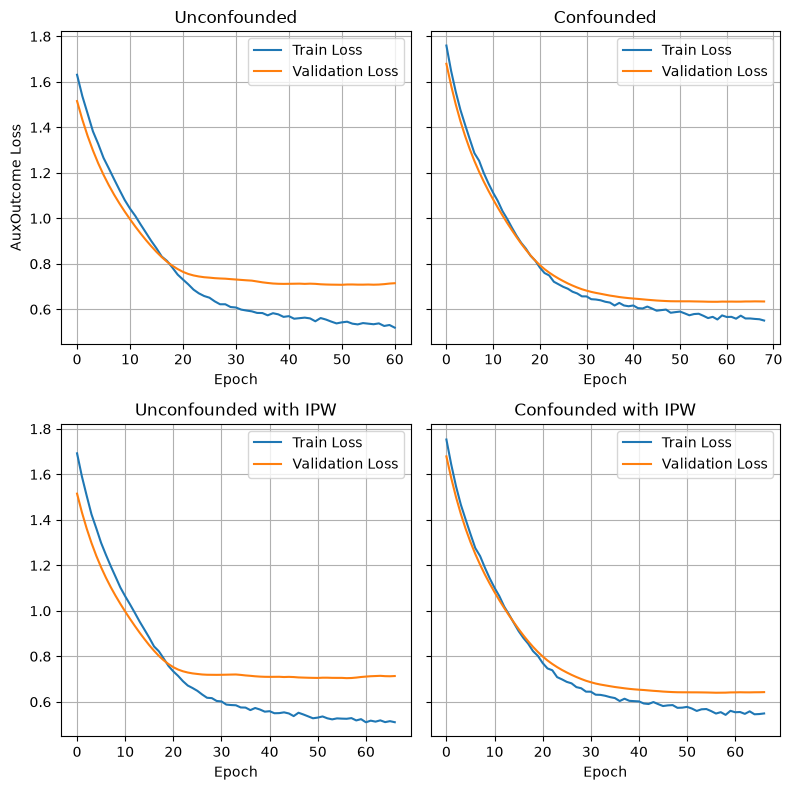

In [11]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2, 2, figsize=(8, 8), sharey=True)

ax0.plot(train_losses, label="Train Loss")
ax0.plot(val_losses, label="Validation Loss")
ax0.set_title("Unconfounded")
ax0.set_ylabel("AuxOutcome Loss")

ax1.plot(train_losses_conf, label="Train Loss")
ax1.plot(val_losses_conf, label="Validation Loss")
ax1.set_title("Confounded")

ax2.plot(train_losses_ipw, label="Train Loss")
ax2.plot(val_losses_ipw, label="Validation Loss")
ax2.set_title("Unconfounded with IPW")
ax0.set_ylabel("AuxOutcome Loss")

ax3.plot(train_losses_conf_ipw, label="Train Loss")
ax3.plot(val_losses_conf_ipw, label="Validation Loss")
ax3.set_title("Confounded with IPW")

for ax in (ax0, ax1, ax2, ax3):
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

## Sampling

In [12]:
class AuxOutcomeSampler(nn.Module):
    """Adapts trained AuxOutcome to evaluate()'s sample_outcomes(x, a, K, clip_val) interface.

    `a` is accepted only for interface parity and ignored -- every subject gets both a=0
    and a=1 predictions. `clip_val` is accepted but unused: clipping is a reverse-diffusion
    artifact that doesn't apply to a closed-form Gaussian head, so this diagnostic isn't
    directly comparable to DiffPO/HybridModel on that specific axis.
    """

    def __init__(self, aux_outcome: AuxOutcome):
        super().__init__()
        self.aux_outcome = aux_outcome

    @torch.no_grad()
    def sample_outcomes(
        self, x: torch.Tensor, a: torch.Tensor, K: int = 50, clip_val: float | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Generate K PO samples per subject. Returns y0 (B,K), y1 (B,K)."""
        B = x.shape[0]
        hidden = self.aux_outcome.trunk(x)
        loc0, scale0 = self.aux_outcome.head0(hidden)
        loc1, scale1 = self.aux_outcome.head1(hidden)
        y0 = loc0.unsqueeze(1) + scale0.unsqueeze(1) * torch.randn(B, K, device=x.device)
        y1 = loc1.unsqueeze(1) + scale1.unsqueeze(1) * torch.randn(B, K, device=x.device)
        return y0, y1


def _counterfactual_rmse(aux: AuxOutcome, ds: CausalDataset) -> float:
    """RMSE of aux_outcome's counterfactual prediction against the true counterfactual mean.

    Isolates exactly what a cf-slot anchoring mechanism would consume --
    aux_outcome.mean(x, 1-a), unlike the pooled rmse_y0/rmse_y1 from evaluate().
    """
    x, a = ds.x.to(DEVICE), ds.a.to(DEVICE)
    mu0, mu1 = ds.mu0.to(DEVICE), ds.mu1.to(DEVICE)
    with torch.no_grad():
        cf_pred = aux.mean(x, 1.0 - a)
    true_cf = torch.where(a.bool(), mu0, mu1)
    return (cf_pred - true_cf).pow(2).mean().sqrt().item()

In [13]:
torch.manual_seed(cfg.train.seed)

sampler = AuxOutcomeSampler(aux_outcome)

result = evaluate(sampler, val_loader, K=50, device=DEVICE, sigma=1.0 / val_ds.y_std)
result["rmse_cf"] = _counterfactual_rmse(aux_outcome, val_ds)

In [14]:
torch.manual_seed(cfg.train.seed)

sampler_conf = AuxOutcomeSampler(aux_outcome_conf)

result_conf = evaluate(
    sampler_conf, val_loader_conf, K=50, device=DEVICE, sigma=1.0 / val_ds_conf.y_std
)
result_conf["rmse_cf"] = _counterfactual_rmse(aux_outcome_conf, val_ds_conf)

In [15]:
torch.manual_seed(cfg.train.seed)

sampler = AuxOutcomeSampler(aux_outcome_ipw)

result_ipw = evaluate(sampler, val_loader, K=50, device=DEVICE, sigma=1.0 / val_ds.y_std)
result_ipw["rmse_cf"] = _counterfactual_rmse(aux_outcome_ipw, val_ds)

In [16]:
torch.manual_seed(cfg.train.seed)

sampler_conf = AuxOutcomeSampler(aux_outcome_conf_ipw)

result_conf_ipw = evaluate(
    sampler_conf, val_loader_conf, K=50, device=DEVICE, sigma=1.0 / val_ds_conf.y_std
)
result_conf_ipw["rmse_cf"] = _counterfactual_rmse(aux_outcome_conf_ipw, val_ds_conf)

In [17]:
for k in (
    "wasserstein_y0",
    "wasserstein_y1",
    "width_95_y0",
    "width_95_y1",
    "width_99_y0",
    "width_99_y1",
    "rmse_y0",
    "rmse_y1",
    "pehe",
    "rmse_cf",
):
    result[k] *= ytrain_std
    result_conf[k] *= ytrain_std
    result_ipw[k] *= ytrain_std
    result_conf_ipw[k] *= ytrain_std

In [36]:
print("\t\t    no IPW\t   with IPW")
print("\t\tUnconf.\tConf.\tUnconf.\tConf.")

for k in result:
    print(
        f"{k:>15}\t{result[k]:>6.3f}\t{result_conf[k]:>5.3f}\t{result_ipw[k]:>6.3f}\t{result_conf_ipw[k]:>5.3f}"
    )

		    no IPW	   with IPW
		Unconf.	Conf.	Unconf.	Conf.
 wasserstein_y0	 0.344	0.550	 0.343	0.558
 wasserstein_y1	 0.418	0.399	 0.423	0.401
 coverage_95_y0	 1.000	0.993	 1.000	0.986
 coverage_95_y1	 1.000	1.000	 1.000	1.000
    width_95_y0	 3.567	3.689	 3.538	3.716
    width_95_y1	 3.814	3.659	 3.611	3.709
 coverage_99_y0	 1.000	0.993	 1.000	0.993
 coverage_99_y1	 1.000	1.000	 1.000	1.000
    width_99_y0	 4.278	4.607	 4.276	4.541
    width_99_y1	 4.517	4.357	 4.280	4.365
        rmse_y0	 0.378	0.691	 0.377	0.700
        rmse_y1	 0.465	0.441	 0.467	0.441
           pehe	 0.660	0.833	 0.646	0.837
        rmse_cf	 0.370	0.612	 0.385	0.615
